In [1]:
pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Apple stock data download
data = yf.download(
    "AAPL",
    start="2024-01-01",
    end="2026-05-05"
)

# first 5 rows show karo
print(data.head())

/tmp/ipykernel_5117/6352678.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.731308  186.502522  181.999301  185.225777  82488700
2024-01-03  182.355637  183.968883  181.544060  182.325946  58414500
2024-01-04  180.039658  181.207518  179.020249  180.277180  71983600
2024-01-05  179.317154  180.880911  178.317544  180.118838  62379700
2024-01-08  183.652130  183.691727  179.633876  180.217806  59144500


In [5]:
# dataset shape
print(data.shape)

# columns names
print(data.columns)

# information
print(data.info())

# statistical summary
print(data.describe())

(586, 5)
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 586 entries, 2024-01-02 to 2026-05-04
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   586 non-null    float64
 1   (High, AAPL)    586 non-null    float64
 2   (Low, AAPL)     586 non-null    float64
 3   (Open, AAPL)    586 non-null    float64
 4   (Volume, AAPL)  586 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 27.5 KB
None
Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL          AAPL
count   586.000000  586.000000  586.000000  586.000000  5.860000e+02
mean    224.741479  226.938072  222.381740  224.562994  5.443336e+07
std      31.075061   3

In [7]:
X = data[["Open", "High", "Low", "Volume"]] #input

y = data["Close"] #output

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)# split data 20% our 80%

In [9]:
from sklearn.linear_model import LinearRegression

# model create
model = LinearRegression()

# model train
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

print(y_pred)

[[255.9059684 ]
 [244.88845771]
 [257.89088569]
 [210.44675251]
 [225.11921826]
 [181.57415751]
 [209.80599432]
 [228.47457848]
 [263.29498686]
 [223.50235145]
 [258.59453883]
 [175.88086535]
 [208.42825051]
 [241.68835435]
 [235.07221133]
 [220.46790926]
 [229.41344099]
 [200.31227162]
 [272.29954571]
 [226.35800042]
 [239.13001692]
 [230.20967207]
 [180.0961445 ]
 [253.2891836 ]
 [229.20316971]
 [168.74359969]
 [170.91336303]
 [270.13306101]
 [246.58631072]
 [182.77313087]
 [270.55298242]
 [238.71160564]
 [269.94766794]
 [253.37595121]
 [170.55331564]
 [195.8633592 ]
 [243.44187725]
 [221.26556929]
 [256.59842727]
 [255.36285392]
 [257.91570532]
 [222.44863236]
 [213.65021079]
 [180.08453407]
 [235.98954142]
 [269.76215535]
 [183.85900638]
 [275.04583808]
 [196.13604901]
 [227.60097552]
 [221.04072237]
 [260.75391484]
 [169.12687103]
 [261.80797874]
 [250.74734821]
 [226.9529563 ]
 [189.42191948]
 [180.69934304]
 [211.93214498]
 [187.58803644]
 [164.96427716]
 [279.68349975]
 [247.86

In [11]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", error)

Mean Absolute Error: 0.9935413192527097


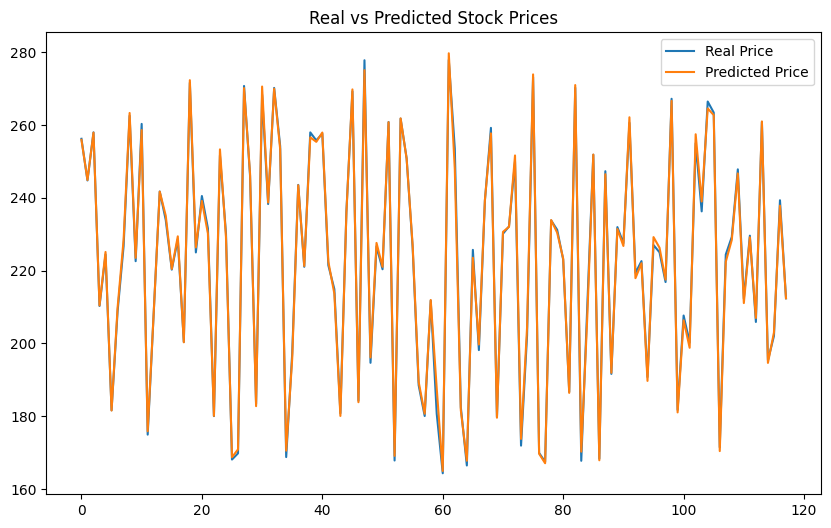

In [12]:
plt.figure(figsize=(10,6))

# real prices
plt.plot(y_test.values, label="Real Price")

# predicted prices
plt.plot(y_pred, label="Predicted Price")

# labels show karo
plt.legend()

# graph title
plt.title("Real vs Predicted Stock Prices")

# graph show karo
plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor

#model create
model = RandomForestRegressor()
model.fit(X_train, y_train)
Y_pred = model.predict(X_test)
print(y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[256.64388718 244.65636734 259.74041443 208.45712326 226.77050491
 182.34338242 211.21754059 227.91708038 263.88861908 224.05149567
 258.33896118 173.843479   209.78562637 242.08016403 236.1916777
 220.7849971  230.7248761  200.7236882  272.08483826 226.91060532
 238.21547012 231.04822052 180.47523163 252.02884537 230.34541473
 167.70118561 172.40066299 270.89347382 244.63064148 183.51194809
 267.76198364 237.36070145 269.58068878 253.79381882 172.07522415
 190.50909927 241.98141159 222.62684189 257.83802353 258.06090607
 257.85770218 221.92096909 214.02705307 179.55070862 237.14788879
 269.66126678 183.94790344 275.19156097 194.22483368 227.25781769
 221.67693954 260.29798035 170.12476654 261.52127686 250.03180389
 227.66453873 189.46825394 181.23423264 211.59006836 186.0838324
 165.07637039 277.65123932 250.08639252 182.2864006  167.4270787
 224.63831039 199.42393143 239.72709412 259.2863269  180.68829407
 230.92194122 230.88376694 251.46575302 173.54715622 203.27083191
 273.46302887

In [20]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", error)
#

Mean Absolute Error: 1.2569902271335396


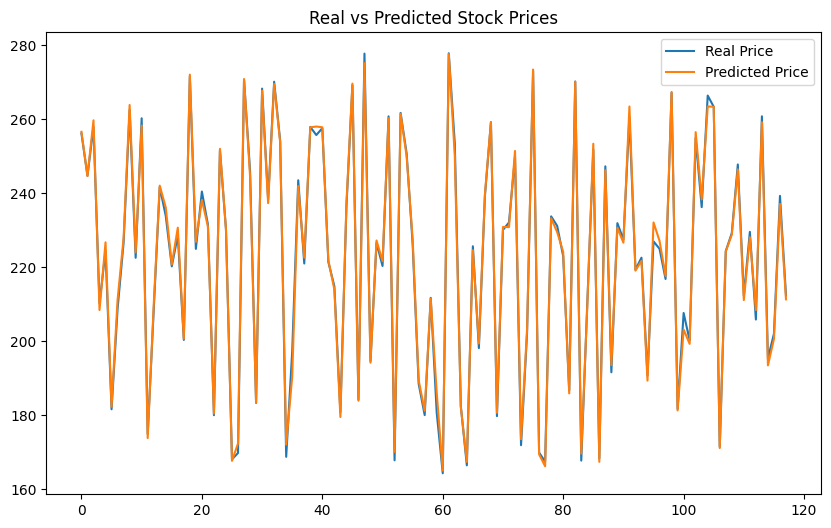

In [21]:
plt.figure(figsize=(10,6))

# real prices
plt.plot(y_test.values, label="Real Price")

# predicted prices
plt.plot(y_pred, label="Predicted Price")

# labels show karo
plt.legend()

plt.title("Real vs Predicted Stock Prices")

plt.show()